In [2]:
# !pip install scikit-learn

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
df=pd.read_csv('Salary_Data.csv')

In [8]:
df.isna().sum().sum()

np.int64(0)

In [9]:
df.head(5)

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


<Axes: xlabel='YearsExperience', ylabel='Salary'>

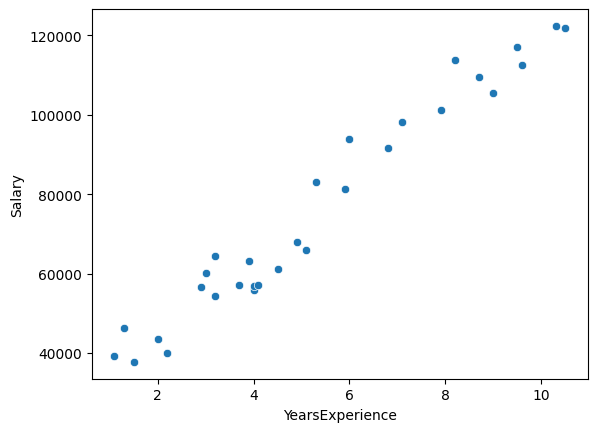

In [10]:
sns.scatterplot(x=df['YearsExperience'],y=df['Salary'])

In [11]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


* The relation between the feature and the target is very strong, so they are highly correlated.
* So this is a linear dataset

In [ ]:
X = df[['YearsExperience']]   # we have to assign it as 2-D because the fit method always takes x as 2-D only.
y = df['Salary']

# train_test_split
* Syntax:
xtrain, xtest, ytrain, ytest= trsin_test_split(X, y train_size=0.8, random_state=42 )
* It is method and it returns a list of 4 values

In [13]:
result= train_test_split(X, y, train_size=0.8)
len(result)

4

In [14]:
result[0]

,YearsExperience
14,4.5
1,1.3
13,4.1
25,9.0
18,5.9
4,2.2
3,2.0
17,5.3
16,5.1
29,10.5


In [15]:
result[1]

,YearsExperience
28,10.3
8,3.2
27,9.6
24,8.7
10,3.9
22,7.9


 # random_state
 * it fix the randomness in the data
 * we can give any number , but usually we give it as 42

In [16]:
xtrain, xtest, ytrain, ytest = train_test_split(X, y, train_size=0.8, random_state=42) #random_state-->it fix the randomness in the data

In [17]:
ytrain

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [18]:
#model Creation
model = LinearRegression() #creating an object to get the properties of the LinearRegression

# fit()
* we use this to learn the pattern
* Also used in model training
* internally it finds mx+c

In [19]:
# training the model

model.fit(xtrain, ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
model.intercept_
#when the years experience is zeo the salary will be 25321.58

np.float64(25321.583011776813)

In [21]:
model.coef_ #slope or weights
# weights tells the importance of feature
# the rate of change of salary when years experience change by 1 unit is 9423.81

array([9423.81532303])

In [22]:
y_train_pred = model.predict(xtrain)

In [23]:
Errors = ytrain-y_train_pred

In [24]:
Errors

28        4.119161
24     2122.223678
12    -6059.844304
0      3655.220133
4     -6162.976722
16    -7354.041159
5      3991.352551
13    -6878.225836
11    -7222.844304
22     1532.275936
1      8632.457068
2     -1726.305996
25    -4553.920919
3      -644.213658
21     6042.328195
26     2121.171419
18      440.906582
29    -2399.643904
20     2334.472792
7     -1032.792045
10     1143.537228
14    -6617.751965
19    12075.525050
6      6556.971019
Name: Salary, dtype: float64

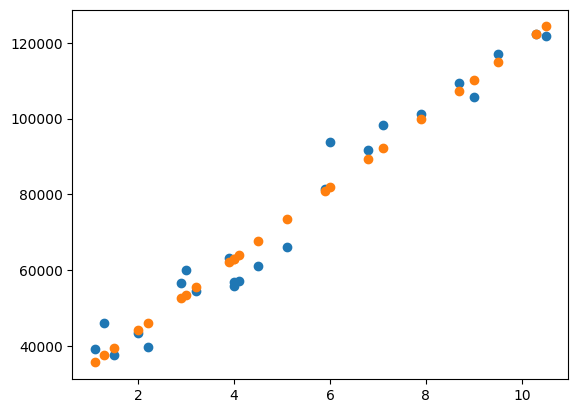

In [25]:
plt.scatter(xtrain,ytrain)
plt.scatter(xtrain,y_train_pred)

In [26]:
y_test_pred = model.predict(xtest)

In [27]:
Errors_test = ytest - y_test_pred

In [28]:
Errors_test

27    -3155.210113
15    -3560.278095
23    11215.131339
17     7820.195776
8      8967.207955
9     -3000.699707
Name: Salary, dtype: float64

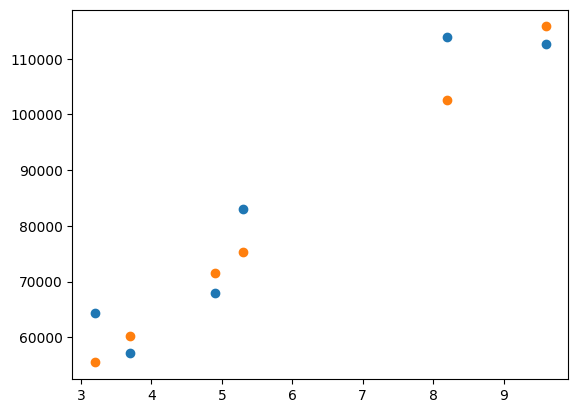

In [29]:
plt.scatter(xtest,ytest)
plt.scatter(xtest,y_test_pred)

In [30]:
model.score(xtrain, ytrain)

0.9645401573418146

In [31]:
model.score(xtest,ytest)

0.9024461774180497

In [34]:
model.predict([[30]])

c:\Users\Test\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([308036.04270271])